# 02. Czyszczenie Danych i Zaawansowana Analiza Eksploracyjna (EDA)

> Poprzedni notebook: [01_data_exploration.ipynb](01_data_exploration.ipynb)

## Cel:
- Czyszczenie i filtracja danych bioaktywności
- Obliczanie deskryptorów molekularnych z RDKit
- Zaawansowana analiza eksploracyjna
- Przygotowanie danych do modelowania

## Plan działania:
1. **Wczytanie danych** - użycie próbki z notebook 01 lub pobranie pełnego datasetu
2. **Czyszczenie danych** - filtracja, usuwanie duplikatów, obsługa outlierów
3. **Feature Engineering** - obliczanie deskryptorów molekularnych
4. **EDA** - wizualizacja i analiza zależności
5. **Eksport** - zapis oczyszczonych danych

---

## Tryb pracy:
Ten notebook może działać w dwóch trybach (kontrolowane przez `USE_SAMPLE`):

**Tryb 1: Próbka (USE_SAMPLE = True)** Domyślny
- Używa zapisanej próbki 100k rekordów z notebook 01
- Szybkie - dane wczytywane z pliku Parquet
- Idealne do rozwoju i testowania

**Tryb 2: Pełny dataset (USE_SAMPLE = False)** (Brak implementacji)
- Pobiera wszystkie dane bezpośrednio z bazy ChEMBL
- Wolne - może zająć kilka minut
- Do finalnego treningu modelu

---

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, AllChem
from rdkit.Chem import rdMolDescriptors

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Biblioteki zostały załadowane pomyślnie.")

Biblioteki zostały załadowane pomyślnie.


## 1. Konfiguracja i Wczytanie Danych

### Źródło danych:
- **Tryb próbki**: Wczytuje zapisaną próbkę z notebook 01 (szybkie)
- **Tryb pełny**: Pobiera wszystkie dane z bazy ChEMBL (wolne, dla produkcji)

Zmień `USE_SAMPLE` w następnej komórce, aby przełączyć między trybami.

In [ ]:
BASE_DIR_PATH = r'<GŁÓWNA_ŚCIEŻKA_PROJEKTU>'  # Zmień na swoją ścieżkę
BASE_DIR = Path(BASE_DIR_PATH)

# Konfiguracja: uzyc próbki z notebook 01 czy pełny dataset z bazy?
# True = użyj zapisanej próbki (100k rekordów) - szybkie, dla testów/rozwoju
# False = pobierz pełny dataset z bazy - wolne, dla finalnego modelu
USE_SAMPLE = True

DB_DIR_PATHNAME = "db"
DB_FILENAME = "chembl_36.db"
DB_PATH = BASE_DIR / DB_DIR_PATHNAME / DB_FILENAME

# Ścieżki do zapisanych danych z notebook 01
SAMPLE_DATA_DIR = BASE_DIR / "data" / "raw"
SAMPLE_FILE_PARQUET = SAMPLE_DATA_DIR / "bioactivity_sample_100k.parquet"
SAMPLE_FILE_CSV = SAMPLE_DATA_DIR / "bioactivity_sample_100k.csv"

if USE_SAMPLE:
    print("TRYB: Używanie zapisanej próbki z notebook 01")
else:
    print("BRAK IMPLEMENTACJI DLA TRYBU PEŁNEGO DATASETU")

TRYB: Używanie zapisanej próbki z notebook 01


In [3]:
if USE_SAMPLE:
    print("Wczytywanie danych z zapisanego pliku...")
    print(f"Źródło: {SAMPLE_FILE_PARQUET.name}\n")
    
    if SAMPLE_FILE_PARQUET.exists():
        try:
            df = pd.read_parquet(SAMPLE_FILE_PARQUET)
            print(f"Wczytano dane z: {SAMPLE_FILE_PARQUET}")
        except Exception as e:
            if "pandas.period already defined" in str(e) and SAMPLE_FILE_CSV.exists():
                print("Wystąpił błąd PyArrow (pandas.period). Fallback do CSV...")
                df = pd.read_csv(SAMPLE_FILE_CSV)
                print(f"Wczytano dane z: {SAMPLE_FILE_CSV}")
            else:
                raise
    elif SAMPLE_FILE_CSV.exists():
        df = pd.read_csv(SAMPLE_FILE_CSV)
        print(f"Wczytano dane z: {SAMPLE_FILE_CSV}")
    else:
        raise FileNotFoundError(
            f"Nie znaleziono pliku z próbką danych!\n"
            f"Oczekiwano: {SAMPLE_FILE_PARQUET} lub {SAMPLE_FILE_CSV}\n"
            f"Uruchom najpierw notebook 01_data_exploration.ipynb"
        )
    
    print(f"\nPobrano {len(df):,} rekordów z zapisanej próbki")
    
else:
    print("BRAK IMPLEMENTACJI DLA TRYBU PEŁNEGO DATASETU")

print(f"Wymiary: {df.shape}")
print(f"Zużycie pamięci: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Wczytywanie danych z zapisanego pliku...
Źródło: bioactivity_sample_100k.parquet

Wczytano dane z: /Users/lukasz/Documents/Python/chembl/data/raw/bioactivity_sample_100k.parquet

Pobrano 100,000 rekordów z zapisanej próbki
Wymiary: (100000, 21)
Zużycie pamięci: 46.02 MB


In [4]:
# Podgląd danych
print("Pierwsze 3 rekordy:")
df.head(3)

Pierwsze 3 rekordy:


,activity_id,molregno,molecule_chembl_id,assay_id,assay_chembl_id,tid,target_chembl_id,target_name,target_type,standard_type,standard_relation,standard_value,standard_units,pchembl_value,assay_type,confidence_score,canonical_smiles,standard_inchi,standard_inchi_key,activity_category,molecule_size_category
0,27402881,2973007,CHEMBL5756006,2590350,CHEMBL5733049,11177,CHEMBL3130,"Phosphatidylinositol 4,5-bisphosphate 3-kinase...",SINGLE PROTEIN,IC50,=,2.0,nM,8.7,B,9,Cc1ccc(-c2cc(C#N)c3c(N)ncnn23)cc1N1CCN(S(C)(=O...,InChI=1S/C21H23N7O3S/c1-13-5-6-14(17-10-15(11-...,WLXCWFBYKVNBNW-UHFFFAOYSA-N,Wysoką (1-10 nM),Średnie (60-100)
1,11794147,925405,CHEMBL1501521,845196,CHEMBL2114807,102639,CHEMBL5990,Breast cancer type 1 susceptibility protein,SINGLE PROTEIN,Potency,NaN,6309.6,nM,NaN,F,9,O=C(c1ccc2c3n(nc2c1)-c1ccc(Cl)cc1CO3)N1CCOCC1,InChI=1S/C19H16ClN3O3/c20-14-2-4-17-13(9-14)11...,FNKNLQYQGFFOMX-UHFFFAOYSA-N,Niską (1-10 μM),Małe (30-60)
2,17902659,596528,CHEMBL592445,1642894,CHEMBL3991714,116956,CHEMBL3879831,"Ferrochelatase, mitochondrial",SINGLE PROTEIN,Kd,>,30000.0,nM,NaN,B,9,CN(C)C1CCN(C(=O)c2ccc(NC(=O)Nc3ccc(-c4nc(N5CCO...,InChI=1S/C32H41N9O4/c1-38(2)27-11-13-39(14-12-...,DWZAEMINVBZMHQ-UHFFFAOYSA-N,Bardzo niską (>10 μM),Średnie (60-100)


In [5]:
# Informacje o datasecie
print("Informacje o datasecie:")
df.info()

Informacje o datasecie:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   activity_id             100000 non-null  int64   
 1   molregno                100000 non-null  int64   
 2   molecule_chembl_id      100000 non-null  str     
 3   assay_id                100000 non-null  int64   
 4   assay_chembl_id         100000 non-null  str     
 5   tid                     100000 non-null  int64   
 6   target_chembl_id        100000 non-null  str     
 7   target_name             100000 non-null  str     
 8   target_type             100000 non-null  str     
 9   standard_type           100000 non-null  str     
 10  standard_relation       71988 non-null   str     
 11  standard_value          100000 non-null  float64 
 12  standard_units          100000 non-null  str     
 13  pchembl_value           59119 non-null   float6

## 2. Czyszczenie Danych

### Kroki czyszczenia:
1. Sprawdzenie braków danych
2. Usunięcie duplikatów
3. Filtracja wartości outlierów
4. Filtracja na podstawie jakości testów (confidence score)
5. Standaryzacja relacji pomiarowych

In [ ]:
# Zachowaj oryginalny rozmiar dla późniejszych porównań
df_original_size = len(df)

# Braki danych
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Kolumna': missing.index,
    'Braki': missing.values,
    'Procent': missing_pct.values
}).sort_values('Braki', ascending=False)

print("\nBraki danych w kolumnach:")
print(missing_df[missing_df['Braki'] > 0].to_string(index=False))

# Sprawdź kluczowe kolumny dla modelowania
critical_columns = ['canonical_smiles', 'standard_value', 'standard_type']
missing_critical = df[critical_columns].isnull().sum()

print("\n\nBraki w kluczowych kolumnach:")
for col in critical_columns:
    missing_count = missing_critical[col]
    if missing_count > 0:
        print(f"  {col}: {missing_count:,} ({missing_count/len(df)*100:.2f}%)")
    else:
        print(f"  {col}: brak braków")

print(f"\nRozmiar datasetu przed czyszczeniem: {len(df):,} rekordów")


Braki danych w kolumnach:
          Kolumna  Braki  Procent
    pchembl_value  40881   40.881
standard_relation  28012   28.012
activity_category     29    0.029


Braki w kluczowych kolumnach:
  canonical_smiles: brak braków
  standard_value: brak braków
  standard_type: brak braków

Rozmiar datasetu przed czyszczeniem: 100,000 rekordów


In [7]:
# Usunięcie duplikatów
print(f"Rozmiar przed: {len(df):,}")

# Duplikaty na podstawie activity_id (każda aktywność powinna być unikalna)
duplicates_activity = df.duplicated(subset=['activity_id']).sum()
print(f"Duplikaty activity_id: {duplicates_activity:,}")

# Duplikaty molecule + assay (ta sama cząsteczka testowana wielokrotnie w tym samym teście)
duplicates_mol_assay = df.duplicated(subset=['molregno', 'assay_id']).sum()
print(f"Duplikaty molecule-assay: {duplicates_mol_assay:,}")

# Usunięcie duplikatów dla activity_id
df = df.drop_duplicates(subset=['activity_id'])

print(f"\nRozmiar po usunięciu duplikatów: {len(df):,}")
print(f"Usunięto: {duplicates_activity:,} rekordów")

Rozmiar przed: 100,000
Duplikaty activity_id: 0
Duplikaty molecule-assay: 79

Rozmiar po usunięciu duplikatów: 100,000
Usunięto: 0 rekordów


In [8]:
# Filtracja outlierów (wartości ekstremalnych)

# Statystyki przed filtracją
print("Statystyki standard_value PRZED filtracją:")
print(f"  Min: {df['standard_value'].min():.2e} nM")
print(f"  Max: {df['standard_value'].max():.2e} nM")
print(f"  Mediana: {df['standard_value'].median():.2f} nM")

# Stosujemy "rozsądny" zakres:
# - Minimum: 0.001 nM (1 pikomolar) - niższe wartości mogą być błędami
# - Maksimum: 100,000,000 nM (100 mM) - wyższe wartości to praktycznie brak aktywności

min_threshold = 0.001  # 1 pM
max_threshold = 100_000_000  # 100 mM

outliers_low = (df['standard_value'] < min_threshold).sum()
outliers_high = (df['standard_value'] > max_threshold).sum()

print(f"\nOutliery poniżej {min_threshold} nM: {outliers_low:,}")
print(f"Outliery powyżej {max_threshold:,} nM: {outliers_high:,}")
print(f"Łączna liczba outlierów: {outliers_low + outliers_high:,}")

# Filtracja danych
df_clean = df[(df['standard_value'] >= min_threshold) & 
              (df['standard_value'] <= max_threshold)].copy()

print(f"\nRozmiar po usunięciu outlierów: {len(df_clean):,}")
print(f"Usunięto: {len(df) - len(df_clean):,} rekordów ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

print("\nStatystyki standard_value PO filtracji:")
print(f"  Min: {df_clean['standard_value'].min():.2e} nM")
print(f"  Max: {df_clean['standard_value'].max():.2e} nM")
print(f"  Mediana: {df_clean['standard_value'].median():.2f} nM")

Statystyki standard_value PRZED filtracją:
  Min: 0.00e+00 nM
  Max: 4.17e+14 nM
  Mediana: 5623.40 nM

Outliery poniżej 0.001 nM: 36
Outliery powyżej 100,000,000 nM: 26
Łączna liczba outlierów: 62

Rozmiar po usunięciu outlierów: 99,938
Usunięto: 62 rekordów (0.06%)

Statystyki standard_value PO filtracji:
  Min: 1.00e-03 nM
  Max: 1.00e+08 nM
  Mediana: 5623.40 nM


In [9]:
# Filtracja na podstawie jakości testów (confidence score)
print("Rozkład confidence score:")
print(df_clean['confidence_score'].value_counts().sort_index(ascending=False))

# Zachowujemy tylko testy z wysoką pewnością (score >= 6)
# Score 6-9 to wysokiej jakości testy z potwierdzonym targetem
confidence_threshold = 6

below_threshold = (df_clean['confidence_score'] < confidence_threshold).sum()
print(f"\nRekordy poniżej confidence_score {confidence_threshold}: {below_threshold:,} ({below_threshold/len(df_clean)*100:.2f}%)")

df_clean = df_clean[df_clean['confidence_score'] >= confidence_threshold].copy()

print(f"Rozmiar po filtracji confidence: {len(df_clean):,}")
print(f"Zachowano tylko testy z confidence_score >= {confidence_threshold}")

Rozkład confidence score:
confidence_score
9    95553
7     1906
5     2479
Name: count, dtype: int64

Rekordy poniżej confidence_score 6: 2,479 (2.48%)
Rozmiar po filtracji confidence: 97,459
Zachowano tylko testy z confidence_score >= 6


In [10]:
# Standaryzacja relacji (standard_relation)
print("Rozkład standard_relation:")
print(df_clean['standard_relation'].value_counts())

# Dla uproszczenia modelowania, zachowujemy tylko dokładne pomiary (=)
# Pomiary < i > mogą wprowadzić niepewność (censored data)
exact_measurements = (df_clean['standard_relation'] == '=').sum()
inexact_measurements = (df_clean['standard_relation'] != '=').sum()

print(f"\nDokładne pomiary ('='): {exact_measurements:,} ({exact_measurements/len(df_clean)*100:.2f}%)")
print(f"Niedokładne pomiary ('<', '>'): {inexact_measurements:,} ({inexact_measurements/len(df_clean)*100:.2f}%)")

# Tylko dokładne pomiary (=)
df_clean = df_clean[df_clean['standard_relation'] == '='].copy()

print(f"\nRozmiar po filtracji relacji: {len(df_clean):,}")
print(f"Zachowano tylko pomiary z dokładnymi wartościami ('=')")

Rozkład standard_relation:
standard_relation
=     57764
>      8430
<      3112
<=      244
>=      101
~         6
>>        1
Name: count, dtype: int64

Dokładne pomiary ('='): 57,764 (59.27%)
Niedokładne pomiary ('<', '>'): 39,695 (40.73%)

Rozmiar po filtracji relacji: 57,764
Zachowano tylko pomiary z dokładnymi wartościami ('=')


In [ ]:
# Podsumowanie czyszczenia danych
print(f"\nRozmiar początkowy:           {df_original_size:>10,} rekordów")
print(f"Rozmiar po czyszczeniu:       {len(df_clean):>10,} rekordów")
print(f"Usunięto łącznie:             {df_original_size - len(df_clean):>10,} rekordów ({(df_original_size - len(df_clean))/df_original_size*100:.2f}%)")
print(f"Zachowano:                    {len(df_clean)/df_original_size*100:>10.2f}%")

print("\nZastosowane filtry:")
print("  - Usunięcie duplikatów (activity_id)")
print(f"  - Wartości outlierów (0.001 - 100,000,000 nM)")
print(f"  - Confidence score >= 6")
print("  - Tylko dokładne pomiary (standard_relation = '=')")

print("\nStatystyki oczyszczonych danych:")
print(f"  Unikalne molekuły:     {df_clean['molregno'].nunique():,}")
print(f"  Unikalne testy:        {df_clean['assay_id'].nunique():,}")
print(f"  Unikalne targety:      {df_clean['tid'].nunique():,}")
print(f"  Typy aktywności:       {df_clean['standard_type'].nunique()}")

# Reset indeksu
df_clean = df_clean.reset_index(drop=True)
print(f"\nIndeks zresetowany")


Rozmiar początkowy:              100,000 rekordów
Rozmiar po czyszczeniu:           57,764 rekordów
Usunięto łącznie:                 42,236 rekordów (42.24%)
Zachowano:                         57.76%

Zastosowane filtry:
  - Usunięcie duplikatów
  - Wartości outlierów (0.001 - 100,000,000 nM)
  - Confidence score >= 6
  - Tylko dokładne pomiary ('=')

Statystyki oczyszczonych danych:
  Unikalne molekuły:     53,913
  Unikalne testy:        22,968
  Unikalne targety:      2,007
  Typy aktywności:       5

Indeks zresetowany


## 3. Feature Engineering - Obliczanie Deskryptorów Molekularnych

### Co to są deskryptory molekularne?
Deskryptory to numeryczne cechy opisujące właściwości chemiczne i fizyczne cząsteczek. Są niezbędne dla modeli ML, bo algorytmy nie rozumieją SMILES bezpośrednio.

### Kategorie deskryptorów:
1. **Podstawowe właściwości** - masa, liczba atomów, pierścieni
2. **Lipinski's Rule of Five** - właściwości "drug-likeness"
3. **Topologiczne** - kształt, rozgałęzienie
4. **Fizykochemiczne** - logP, polar surface area
5. **Fingerprints** - binarne wektory podobieństwa strukturalnego

In [12]:
# Funkcja do obliczania deskryptorów molekularnych z SMILES
def calculate_molecular_descriptors(smiles):
    """
    Oblicza deskryptory molekularne z SMILES używając RDKit.
    
    Zwraca słownik z deskryptorami lub None jeśli SMILES jest niepoprawny.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    descriptors = {}
    
    try:
        # 1. Podstawowe właściwości
        descriptors['MolecularWeight'] = Descriptors.MolWt(mol)
        descriptors['NumAtoms'] = mol.GetNumAtoms()
        descriptors['NumHeavyAtoms'] = Descriptors.HeavyAtomCount(mol)
        descriptors['NumHeteroatoms'] = Descriptors.NumHeteroatoms(mol)
        
        # 2. Właściwości Lipinski (Rule of Five)
        descriptors['NumHDonors'] = Descriptors.NumHDonors(mol)
        descriptors['NumHAcceptors'] = Descriptors.NumHAcceptors(mol)
        descriptors['LogP'] = Descriptors.MolLogP(mol)
        descriptors['TPSA'] = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # 3. Pierścienie i aromatyczność
        descriptors['NumAromaticRings'] = Descriptors.NumAromaticRings(mol)
        descriptors['NumAliphaticRings'] = Descriptors.NumAliphaticRings(mol)
        descriptors['NumRings'] = Descriptors.RingCount(mol)
        descriptors['AromaticProportion'] = len([atom for atom in mol.GetAtoms() if atom.GetIsAromatic()]) / mol.GetNumAtoms()
        
        # 4. Wiązania
        descriptors['NumRotatableBonds'] = Descriptors.NumRotatableBonds(mol)
        descriptors['NumSaturatedRings'] = Descriptors.NumSaturatedRings(mol)
        
        # 5. Złożoność
        descriptors['FractionCSP3'] = Descriptors.FractionCSP3(mol)
        descriptors['MolMR'] = Descriptors.MolMR(mol)  # Molar Refractivity
        
        # 6. Lipinski Rule of Five - flagi
        descriptors['Lipinski_Violation'] = (
            (descriptors['MolecularWeight'] > 500) +
            (descriptors['LogP'] > 5) +
            (descriptors['NumHDonors'] > 5) +
            (descriptors['NumHAcceptors'] > 10)
        )
        
    except Exception as e:
        print(f"Błąd podczas obliczania deskryptorów: {e}")
        return None
    
    return descriptors

print("Funkcja calculate_molecular_descriptors() zdefiniowana pomyślnie.")

Funkcja calculate_molecular_descriptors() zdefiniowana pomyślnie.


In [13]:
# Oblicz deskryptory dla wszystkich molekuł
print("Obliczanie deskryptorów molekularnych...")
print(f"Liczba molekuł do przetworzenia: {len(df_clean):,}")
print()

from tqdm import tqdm
tqdm.pandas(desc="Obliczanie deskryptorów")

descriptors_list = df_clean['canonical_smiles'].progress_apply(calculate_molecular_descriptors)

# Ile Smiles było niepoprawnych (None)?
invalid_smiles = descriptors_list.isnull().sum()
print(f"\nNiepoprawne SMILES: {invalid_smiles} ({invalid_smiles/len(df_clean)*100:.2f}%)")

# Usunięcie rekordów z niepoprawnym SMILES
if invalid_smiles > 0:
    df_clean = df_clean[descriptors_list.notnull()].copy()
    descriptors_list = descriptors_list[descriptors_list.notnull()]
    print(f"Usunięto {invalid_smiles} rekordów z niepoprawnym SMILES")

# Konwersja na DataFrame
descriptors_df = pd.DataFrame(descriptors_list.tolist())

# Połączenie z oryginalnym dataframe
df_clean = pd.concat([df_clean.reset_index(drop=True), descriptors_df], axis=1)

print(f"\nDeskryptory obliczone pomyślnie!")
print(f"Dodano {len(descriptors_df.columns)} nowych cech molekularnych")
print(f"Nowy wymiar datasetu: {df_clean.shape}")

Obliczanie deskryptorów molekularnych...
Liczba molekuł do przetworzenia: 57,764



Obliczanie deskryptorów: 100%|██████████| 57764/57764 [00:32<00:00, 1793.91it/s]



Niepoprawne SMILES: 0 (0.00%)

Deskryptory obliczone pomyślnie!
Dodano 17 nowych cech molekularnych
Nowy wymiar datasetu: (57764, 38)


In [14]:
print("Obliczone deskryptory molekularne:")
for i, col in enumerate(descriptors_df.columns, 1):
    print(f"{i:2d}. {col}")
    
print(f"\nŁącznie: {len(descriptors_df.columns)} deskryptorów")

Obliczone deskryptory molekularne:
 1. MolecularWeight
 2. NumAtoms
 3. NumHeavyAtoms
 4. NumHeteroatoms
 5. NumHDonors
 6. NumHAcceptors
 7. LogP
 8. TPSA
 9. NumAromaticRings
10. NumAliphaticRings
11. NumRings
12. AromaticProportion
13. NumRotatableBonds
14. NumSaturatedRings
15. FractionCSP3
16. MolMR
17. Lipinski_Violation

Łącznie: 17 deskryptorów


In [15]:
# Stwórz zmienną docelową - pIC50
# pIC50 = -log10(IC50 in M) - im wyższa wartość, tym lepsze związek

# Konwersja z nM do M (molar): 1 nM = 1e-9 M
df_clean['activity_value_M'] = df_clean['standard_value'] * 1e-9

# Obliczenie pActivity (znormalizowane)
df_clean['pActivity'] = -np.log10(df_clean['activity_value_M'])

# Dla IC50 jest to równoznaczne z pIC50
# Wyższe wartości pActivity = bardziej aktywna cząsteczka

print("Stworzono zmienną docelową: pActivity")
print(f"Zakres pActivity: {df_clean['pActivity'].min():.2f} - {df_clean['pActivity'].max():.2f}")
print(f"Średnia: {df_clean['pActivity'].mean():.2f}")
print(f"Mediana: {df_clean['pActivity'].median():.2f}")

print("\n Interpretacja:")
print("  pActivity = -log10(wartość w M)")
print("  Wyższa wartość pActivity = lepsza (bardziej aktywna) cząsteczka")
print("  Przykłady:")
print("    1 nM (1e-9 M) → pActivity = 9.0 (doskonała)")
print("    100 nM (1e-7 M) → pActivity = 7.0 (dobra)")
print("    10,000 nM (1e-5 M) → pActivity = 5.0 (średnia)")

Stworzono zmienną docelową: pActivity
Zakres pActivity: 1.00 - 12.00
Średnia: 6.26
Mediana: 6.10

 Interpretacja:
  pActivity = -log10(wartość w M)
  Wyższa wartość pActivity = lepsza (bardziej aktywna) cząsteczka
  Przykłady:
    1 nM (1e-9 M) → pActivity = 9.0 (doskonała)
    100 nM (1e-7 M) → pActivity = 7.0 (dobra)
    10,000 nM (1e-5 M) → pActivity = 5.0 (średnia)


## 4. Zaawansowana Analiza Eksploracyjna (EDA)

### Cel:
- Zrozumienie rozkładów deskryptorów
- Analiza korelacji z aktywnością
- Identyfikacja najważniejszych cech
- Wykrycie potencjalnych problemów

In [16]:
# Statystyki opisowe deskryptorów molekularnych
print("Statystyki opisowe deskryptorów molekularnych:")

descriptor_columns = descriptors_df.columns.tolist()
stats = df_clean[descriptor_columns].describe().T

# Wprowadzenie mediany do statystyk
stats['median'] = df_clean[descriptor_columns].median()

# Sortowanie według średniej wartości
stats = stats.sort_values('mean', ascending=False)

print(stats.to_string())

print("\nWszystkie deskryptory obliczone poprawnie")

Statystyki opisowe deskryptorów molekularnych:
                      count        mean         std      min         25%        50%         75%        max     median
MolecularWeight     57764.0  442.123654  266.717049   34.083  342.347750  411.47950  482.221250  5588.2820  411.47950
MolMR               57764.0  118.378526   68.058960    0.000   92.585450  110.66030  129.622825  1405.1950  110.66030
TPSA                57764.0   96.390892  111.636222    0.000   60.940000   82.03000  105.550000  2409.3400   82.03000
NumAtoms            57764.0   31.161381   18.749300    1.000   24.000000   29.00000   34.000000   394.0000   29.00000
NumHeavyAtoms       57764.0   31.158749   18.748522    1.000   24.000000   29.00000   34.000000   394.0000   29.00000
NumHeteroatoms      57764.0    8.594090    7.101281    0.000    6.000000    8.00000   10.000000   200.0000    8.00000
NumRotatableBonds   57764.0    6.290510    8.209440    0.000    4.000000    5.00000    7.000000   206.0000    5.00000
NumHAccep

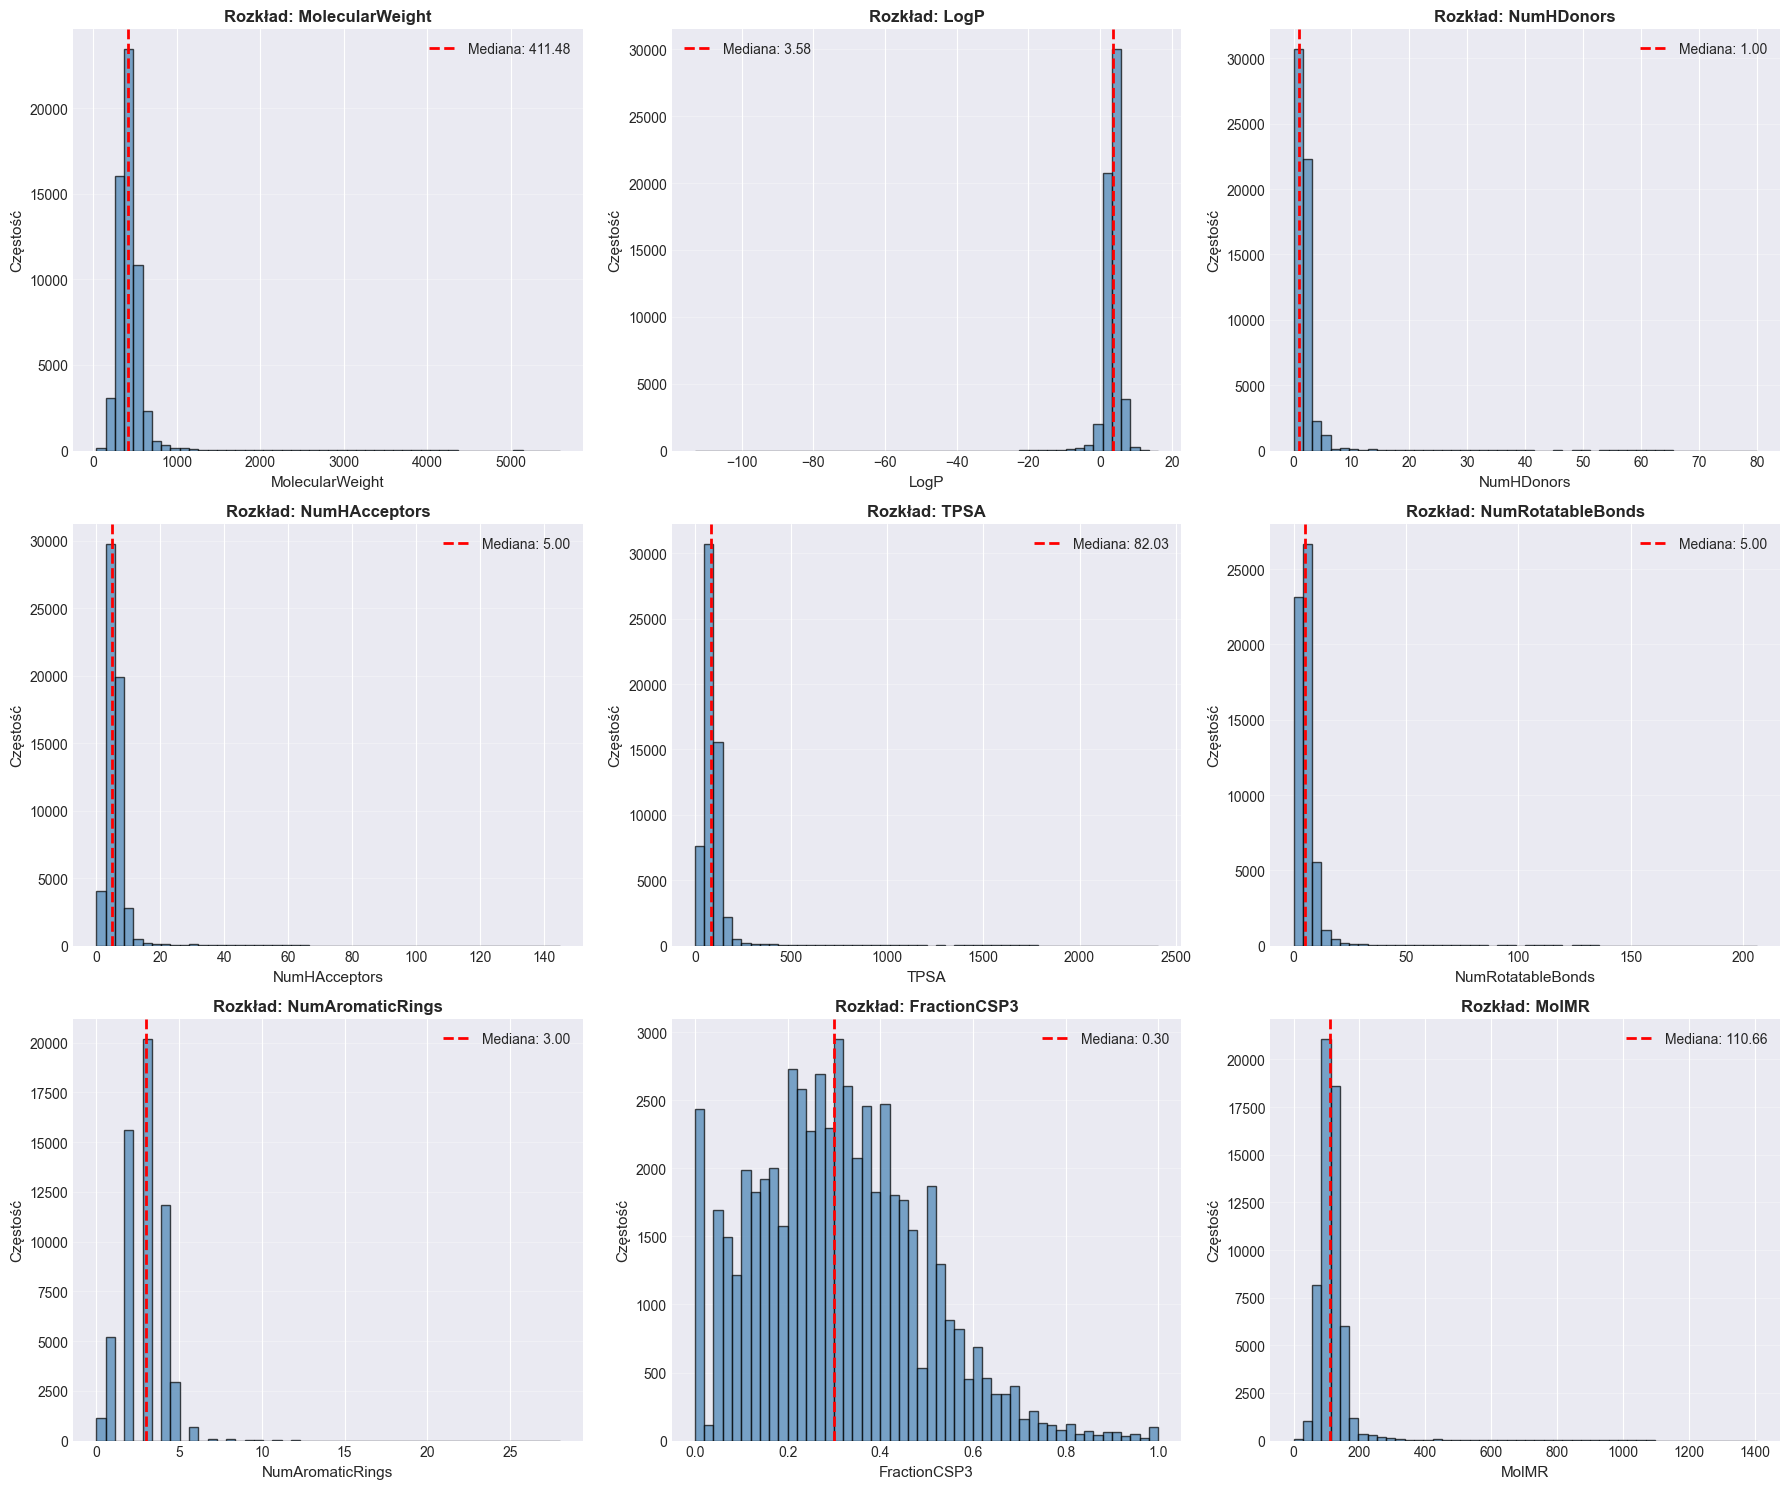

In [17]:
# Rozkłady kluczowych deskryptorów
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

key_descriptors = [
    'MolecularWeight', 'LogP', 'NumHDonors', 'NumHAcceptors',
    'TPSA', 'NumRotatableBonds', 'NumAromaticRings', 
    'FractionCSP3', 'MolMR'
]

for idx, desc in enumerate(key_descriptors):
    ax = axes[idx]
    ax.hist(df_clean[desc], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df_clean[desc].median(), color='red', linestyle='--', 
               linewidth=2, label=f'Mediana: {df_clean[desc].median():.2f}')
    ax.set_xlabel(desc, fontsize=11)
    ax.set_ylabel('Częstość', fontsize=11)
    ax.set_title(f'Rozkład: {desc}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Korelacja deskryptorów z pActivity:

Najsilniejsze pozytywne korelacje (wyższy deskryptor → wyższa aktywność):
NumRings              0.289065
NumSaturatedRings     0.217779
Lipinski_Violation    0.217395
NumAtoms              0.213754
NumHeavyAtoms         0.213645
MolMR                 0.209341
MolecularWeight       0.206751
NumAliphaticRings     0.194330
FractionCSP3          0.187648
NumHeteroatoms        0.183742


Najsilniejsze negatywne korelacje (wyższy deskryptor → niższa aktywność):
NumAliphaticRings     0.194330
FractionCSP3          0.187648
NumHeteroatoms        0.183742
NumAromaticRings      0.169291
NumHAcceptors         0.156261
TPSA                  0.141409
NumRotatableBonds     0.140420
NumHDonors            0.130854
LogP                  0.042888
AromaticProportion   -0.088921


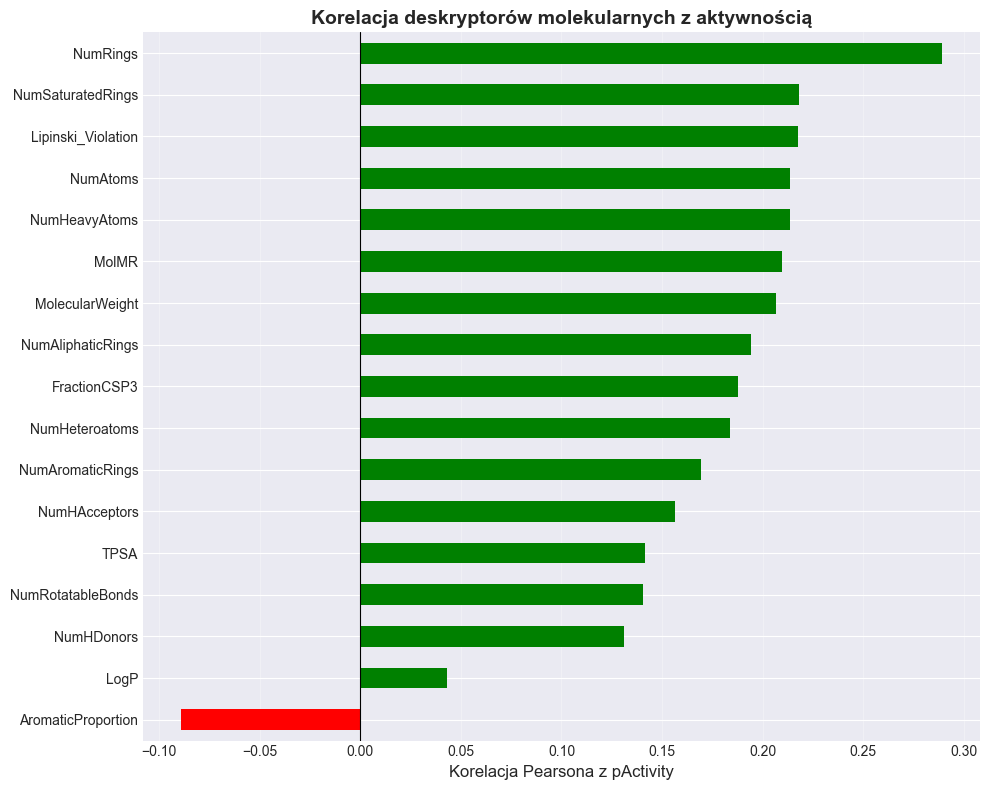

In [18]:
# Analiza korelacji deskryptorów z aktywnością (pActivity)
print("Korelacja deskryptorów z pActivity:")

# Obliczenie korelacji dla każdego deskryptora z pActivity
correlations = df_clean[descriptor_columns].corrwith(df_clean['pActivity']).sort_values(ascending=False)

print("\nNajsilniejsze pozytywne korelacje (wyższy deskryptor → wyższa aktywność):")
print(correlations.head(10).to_string())

print("\n\nNajsilniejsze negatywne korelacje (wyższy deskryptor → niższa aktywność):")
print(correlations.tail(10).to_string())

# Wizualizacja korelacji
fig, ax = plt.subplots(figsize=(10, 8))
correlations.sort_values().plot(kind='barh', ax=ax, color=['red' if x < 0 else 'green' for x in correlations.sort_values()])
ax.set_xlabel('Korelacja Pearsona z pActivity', fontsize=12)
ax.set_title('Korelacja deskryptorów molekularnych z aktywnością', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

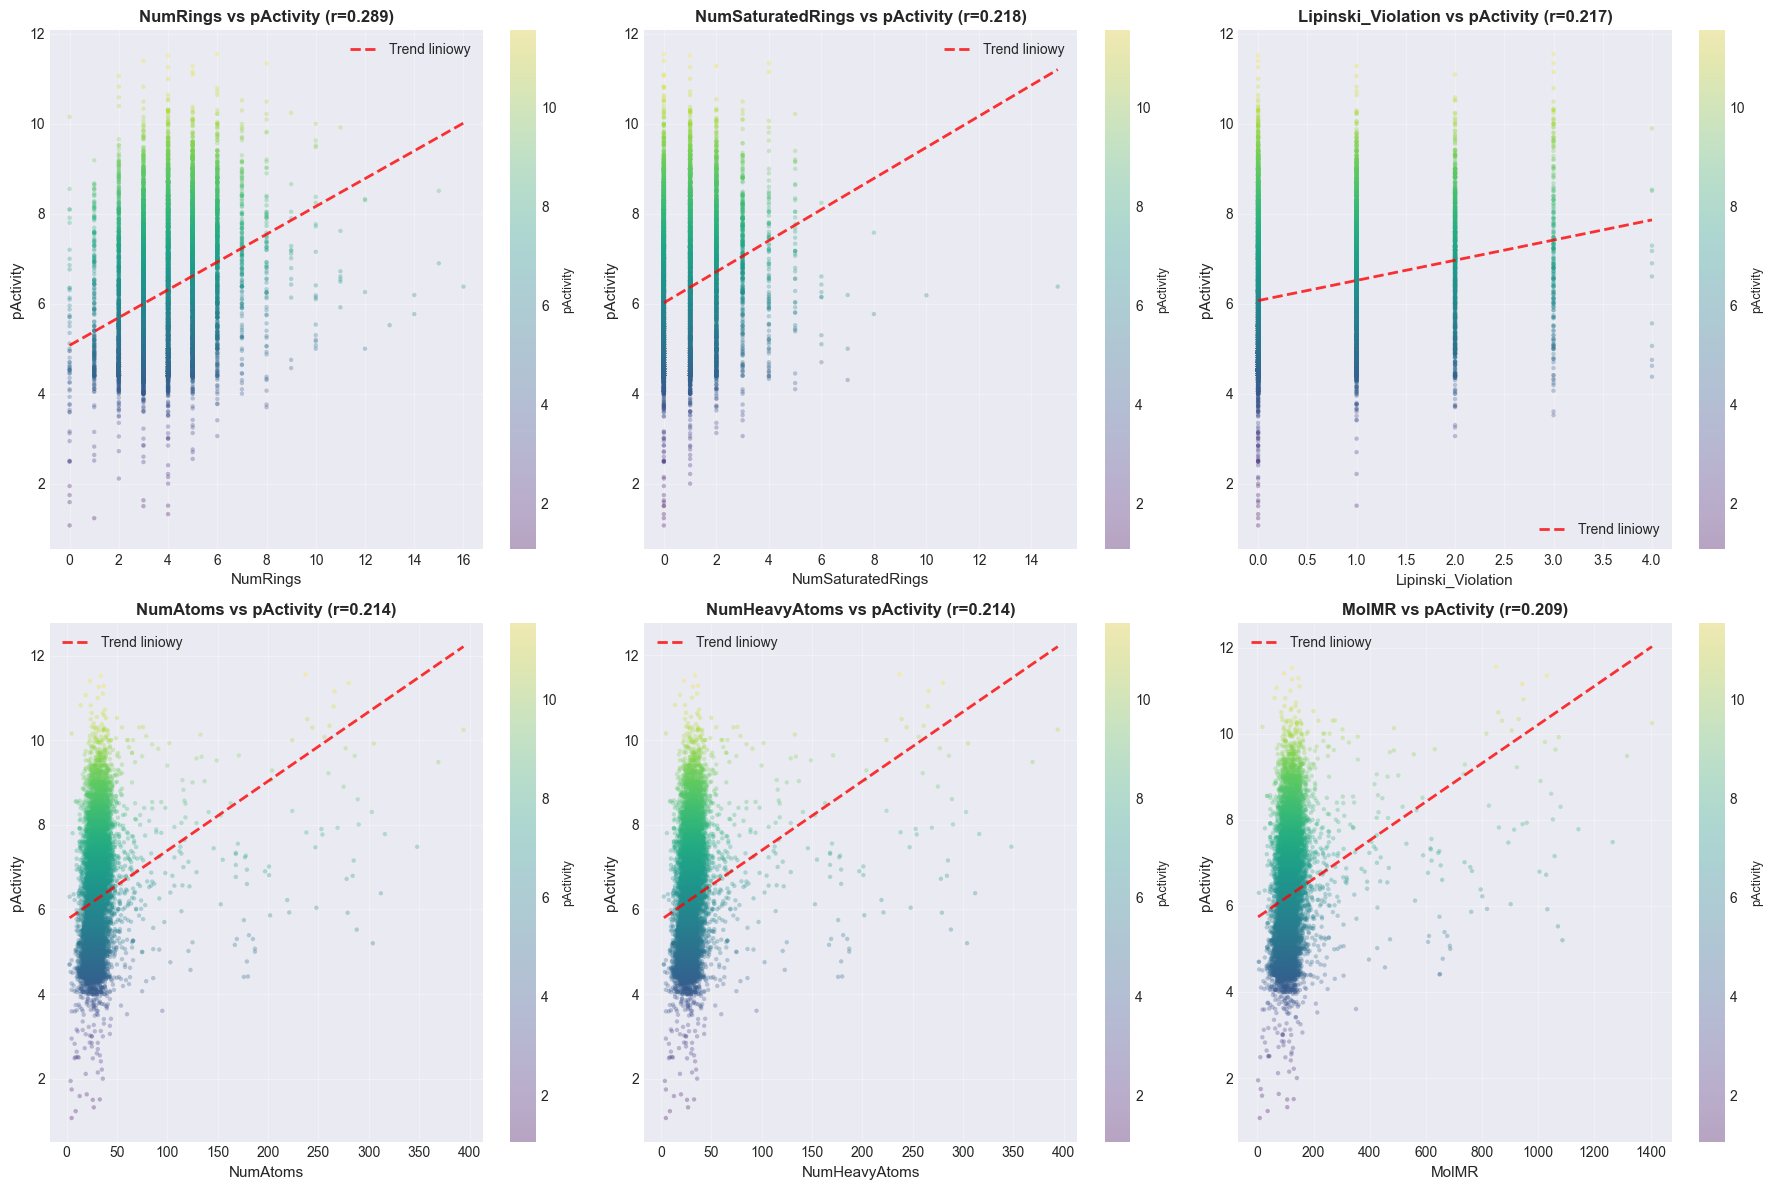

In [19]:
# Najlepsza 6 skorelowanych deskryptorów
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

top_correlations = correlations.abs().sort_values(ascending=False).head(6)

for idx, (desc, corr_val) in enumerate(top_correlations.items()):
    ax = axes[idx]
    
    if len(df_clean) > 10000:
        sample_df = df_clean.sample(10000, random_state=42)
    else:
        sample_df = df_clean
    
    scatter = ax.scatter(sample_df[desc], sample_df['pActivity'], 
                        alpha=0.3, s=10, c=sample_df['pActivity'], 
                        cmap='viridis', edgecolors='none')
    
    # Linia trendu
    z = np.polyfit(sample_df[desc], sample_df['pActivity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample_df[desc].min(), sample_df[desc].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend liniowy')
    
    ax.set_xlabel(desc, fontsize=11)
    ax.set_ylabel('pActivity', fontsize=11)
    ax.set_title(f'{desc} vs pActivity (r={corr_val:.3f})', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('pActivity', fontsize=9)

plt.tight_layout()
plt.show()

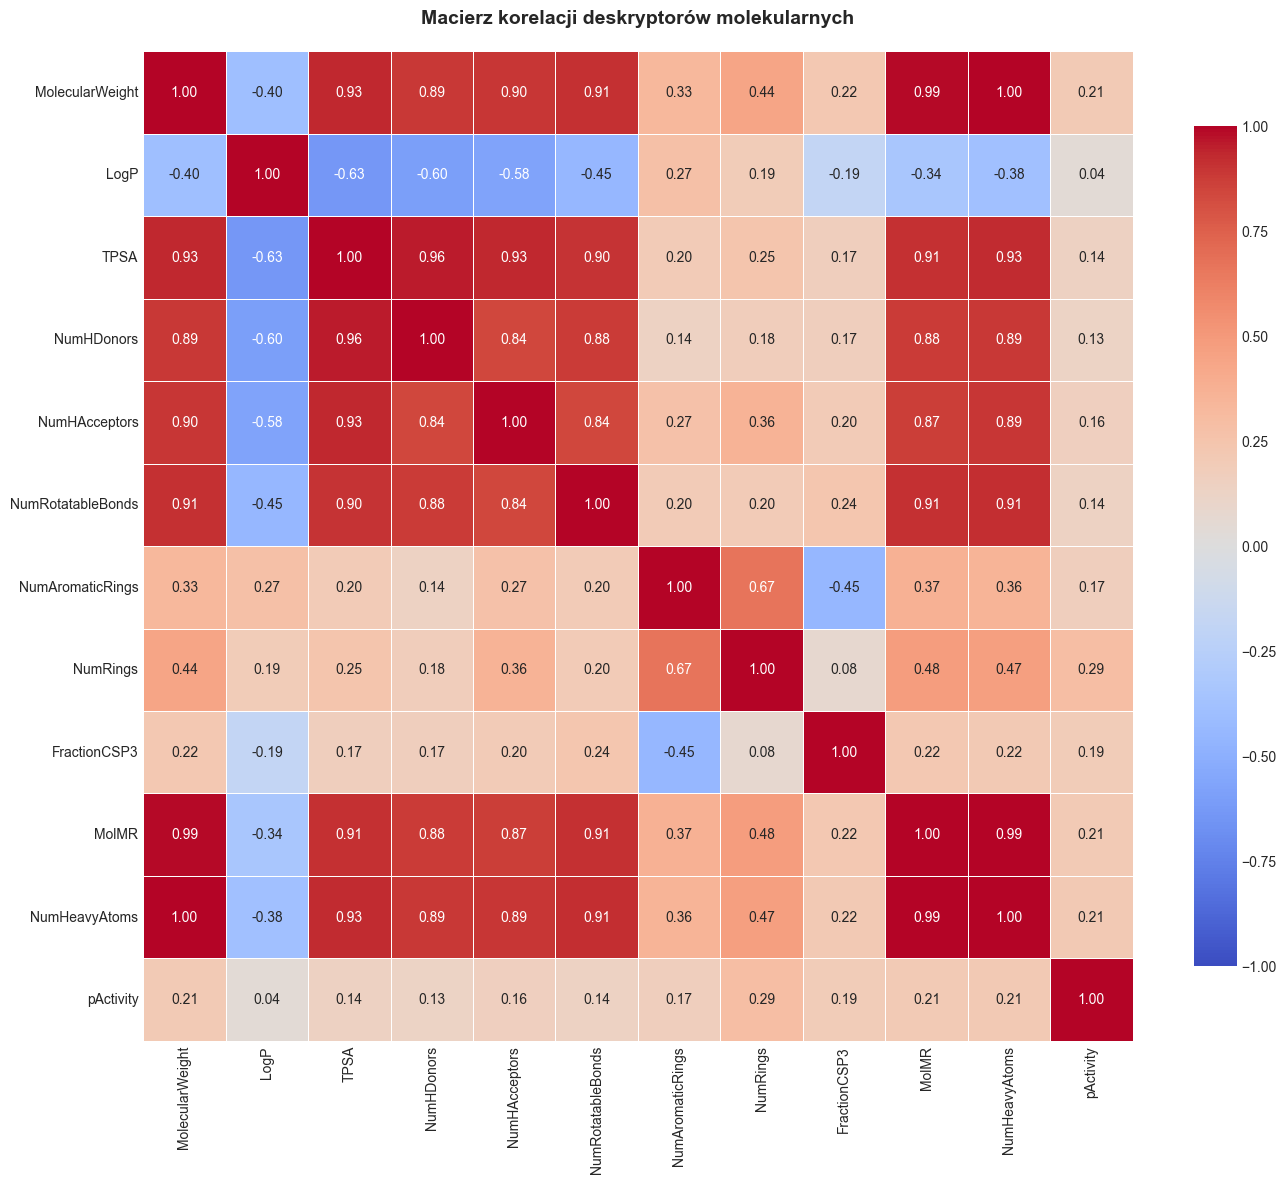


Macierz korelacji pokazuje zależności między deskryptorami
- Czerwony = silna pozytywna korelacja
- Niebieski = silna negatywna korelacja
- Biały = brak korelacji


In [20]:
# Macierz korelacji między deskryptorami
fig, ax = plt.subplots(figsize=(14, 12))

# Wybór tylko kluczowych deskryptorów (dla czytelności)
selected_descriptors = [
    'MolecularWeight', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors',
    'NumRotatableBonds', 'NumAromaticRings', 'NumRings', 'FractionCSP3',
    'MolMR', 'NumHeavyAtoms', 'pActivity'
]

corr_matrix = df_clean[selected_descriptors].corr()

# Heatmapa
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Macierz korelacji deskryptorów molekularnych', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nMacierz korelacji pokazuje zależności między deskryptorami")
print("- Czerwony = silna pozytywna korelacja")
print("- Niebieski = silna negatywna korelacja")
print("- Biały = brak korelacji")

In [21]:
# Analiza Lipinskiego
print("\nReguła Lipińskiego opisuje właściwości molekuł 'drug-like':")
print("1. Masa molekularna ≤ 500 Da")
print("2. LogP ≤ 5 ")
print("3. Liczba donorów wiązań wodorowych ≤ 5")
print("4. Liczba akceptorów wiązań wodorowych ≤ 10")
print("\nMolekulą spełnia regułę jeśli ma maksymalnie 1 naruszenie.")

# Sprawdzenie rozkładu naruszeń reguły Lipińskiego
violations_count = df_clean['Lipinski_Violation'].value_counts().sort_index()

print("\n\nRozkład naruszeń reguły Lipińskiego:")
for n_violations, count in violations_count.items():
    pct = count / len(df_clean) * 100
    if n_violations == 0:
        status = "Pełna zgodność"
    elif n_violations == 1:
        status = "Jedna naruszenie (akceptowalne)"
    else:
        status = "Wiele naruszeń (nie 'drug-like')"
    
    print(f"  {n_violations} naruszeń: {count:>8,} ({pct:>5.2f}%) {status}")

# Procent drug-like molecules (0 lub 1 naruszenie)
drug_like = df_clean[df_clean['Lipinski_Violation'] <= 1].shape[0]
drug_like_pct = drug_like / len(df_clean) * 100

print(f"\n\nMolekuły 'drug-like' (0 lub 1 naruszenie): {drug_like:,} ({drug_like_pct:.2f}%)")


Reguła Lipińskiego opisuje właściwości molekuł 'drug-like':
1. Masa molekularna ≤ 500 Da
2. LogP ≤ 5 
3. Liczba donorów wiązań wodorowych ≤ 5
4. Liczba akceptorów wiązań wodorowych ≤ 10

Molekulą spełnia regułę jeśli ma maksymalnie 1 naruszenie.


Rozkład naruszeń reguły Lipińskiego:
  0 naruszeń:   40,678 (70.42%) Pełna zgodność
  1 naruszeń:   10,617 (18.38%) Jedna naruszenie (akceptowalne)
  2 naruszeń:    5,107 ( 8.84%) Wiele naruszeń (nie 'drug-like')
  3 naruszeń:    1,305 ( 2.26%) Wiele naruszeń (nie 'drug-like')
  4 naruszeń:       57 ( 0.10%) Wiele naruszeń (nie 'drug-like')


Molekuły 'drug-like' (0 lub 1 naruszenie): 51,295 (88.80%)


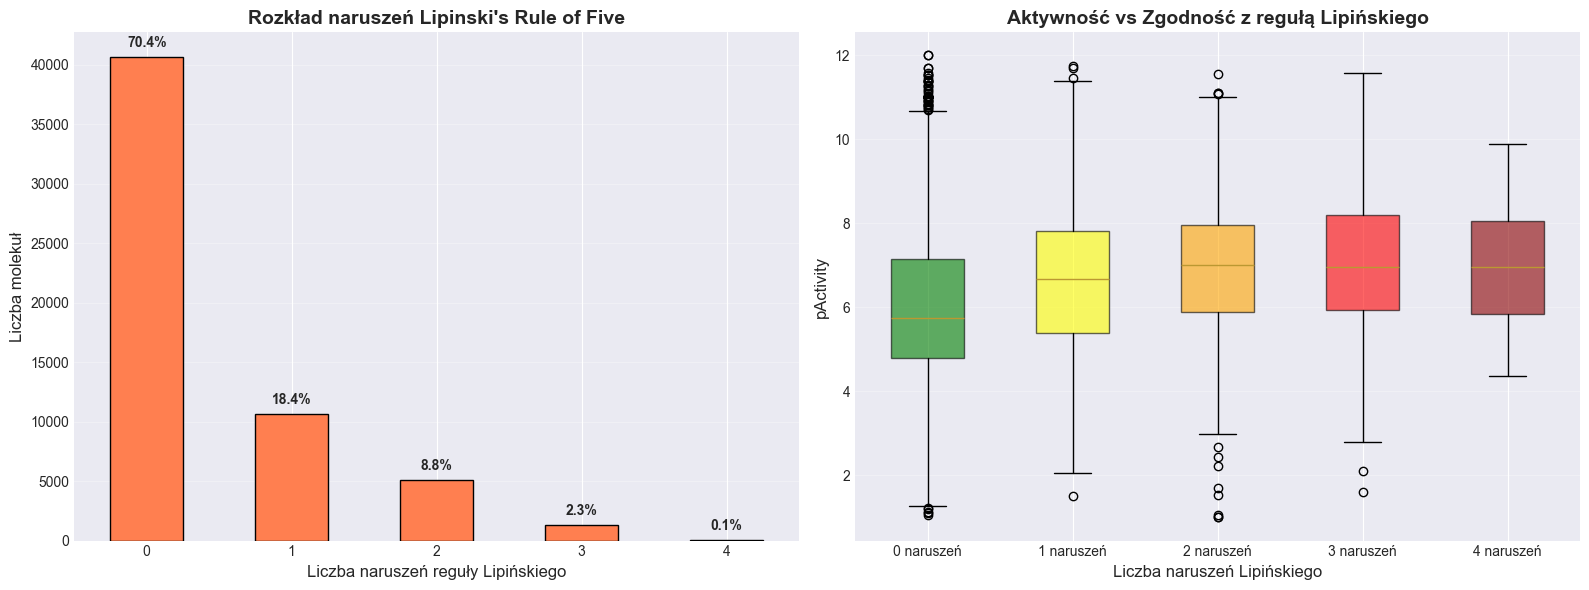

In [22]:
# Wizualizacja naruszeń Lipińskiego
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
violations_count.plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_xlabel('Liczba naruszeń reguły Lipińskiego', fontsize=12)
ax1.set_ylabel('Liczba molekuł', fontsize=12)
ax1.set_title('Rozkład naruszeń Lipinski\'s Rule of Five', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)

for i, (n_viol, count) in enumerate(violations_count.items()):
    pct = count / len(df_clean) * 100
    ax1.text(i, count + len(df_clean)*0.01, f'{pct:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Aktywność vs naruszenia Lipińskiego
ax2 = axes[1]
lipinski_groups = [df_clean[df_clean['Lipinski_Violation'] == i]['pActivity'] 
                   for i in sorted(violations_count.index)]
bp = ax2.boxplot(lipinski_groups, labels=[f'{i} naruszeń' for i in sorted(violations_count.index)],
                 patch_artist=True)

for patch, color in zip(bp['boxes'], ['green', 'yellow', 'orange', 'red', 'darkred'][:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_xlabel('Liczba naruszeń Lipińskiego', fontsize=12)
ax2.set_ylabel('pActivity', fontsize=12)
ax2.set_title('Aktywność vs Zgodność z regułą Lipińskiego', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

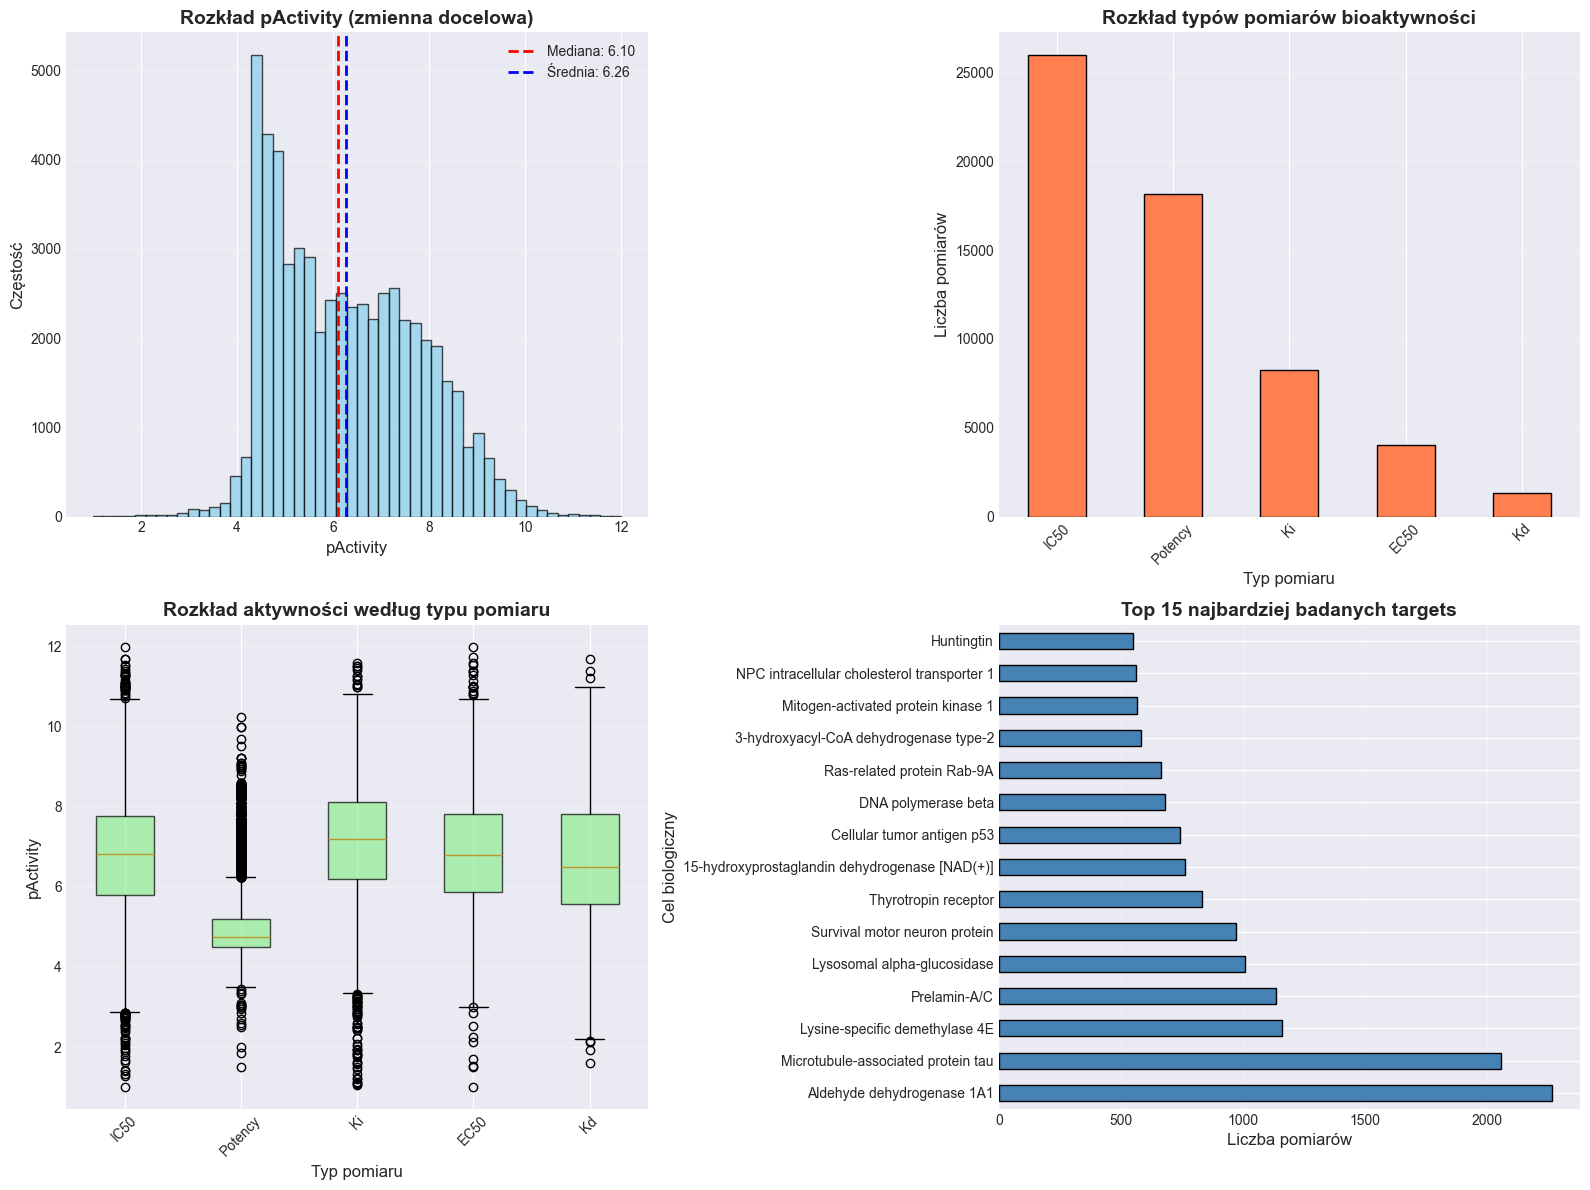

In [23]:
# Analiza rozkładu aktywności i typów pomiarów
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram pActivity
ax1 = axes[0, 0]
ax1.hist(df_clean['pActivity'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(df_clean['pActivity'].median(), color='red', linestyle='--', 
            linewidth=2, label=f'Mediana: {df_clean["pActivity"].median():.2f}')
ax1.axvline(df_clean['pActivity'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Średnia: {df_clean["pActivity"].mean():.2f}')
ax1.set_xlabel('pActivity', fontsize=12)
ax1.set_ylabel('Częstość', fontsize=12)
ax1.set_title('Rozkład pActivity (zmienna docelowa)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Rozkład typów aktywności
ax2 = axes[0, 1]
activity_types = df_clean['standard_type'].value_counts()
activity_types.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_xlabel('Typ pomiaru', fontsize=12)
ax2.set_ylabel('Liczba pomiarów', fontsize=12)
ax2.set_title('Rozkład typów pomiarów bioaktywności', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# pActivity vs typ pomiaru
ax3 = axes[1, 0]
activity_type_data = [df_clean[df_clean['standard_type'] == t]['pActivity'] 
                      for t in activity_types.index]
bp = ax3.boxplot(activity_type_data, labels=activity_types.index, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)
ax3.set_xlabel('Typ pomiaru', fontsize=12)
ax3.set_ylabel('pActivity', fontsize=12)
ax3.set_title('Rozkład aktywności według typu pomiaru', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Najlepsze 15 targetów
ax4 = axes[1, 1]
top_targets = df_clean['target_name'].value_counts().head(15)
top_targets.plot(kind='barh', ax=ax4, color='steelblue', edgecolor='black')
ax4.set_xlabel('Liczba pomiarów', fontsize=12)
ax4.set_ylabel('Cel biologiczny', fontsize=12)
ax4.set_title('Top 15 najbardziej badanych targets', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Eksport Oczyszczonych Danych

### Przygotowanie danych do modelowania

In [24]:
# Finalne przygotowanie danych do eksportu
print("Przygotowanie danych do eksportu...")

columns_to_keep = [
    # Identyfikatory
    'activity_id', 'molregno', 'molecule_chembl_id', 'assay_id', 
    'assay_chembl_id', 'tid', 'target_chembl_id', 'target_name', 'target_type',
    
    # Informacje o pomiarze
    'standard_type', 'standard_value', 'standard_units', 'pchembl_value',
    'assay_type', 'confidence_score',
    
    # Struktura chemiczna
    'canonical_smiles', 'standard_inchi_key',
    
    # Zmienna docelowa
    'pActivity',
    
    # Deskryptory molekularne
    'MolecularWeight', 'NumAtoms', 'NumHeavyAtoms', 'NumHeteroatoms',
    'NumHDonors', 'NumHAcceptors', 'LogP', 'TPSA',
    'NumAromaticRings', 'NumAliphaticRings', 'NumRings', 'AromaticProportion',
    'NumRotatableBonds', 'NumSaturatedRings', 'FractionCSP3', 'MolMR',
    'Lipinski_Violation'
]

df_export = df_clean[columns_to_keep].copy()

print(f"Kolumny do eksportu: {len(columns_to_keep)}")
print(f"Wiersze do eksportu: {len(df_export):,}")
print(f"Wymiar: {df_export.shape}")

Przygotowanie danych do eksportu...
Kolumny do eksportu: 35
Wiersze do eksportu: 57,764
Wymiar: (57764, 35)


In [25]:
# Zapis do pliku CSV
output_dir = BASE_DIR / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "bioactivity_cleaned.csv"

print(f"\nZapisywanie do: {output_file}")
df_export.to_csv(output_file, index=False)

file_size_mb = output_file.stat().st_size / (1024**2)
print(f"Dane zapisane pomyślnie!")
print(f"- Rozmiar pliku: {file_size_mb:.2f} MB")
print(f"- Lokalizacja: {output_file}")


Zapisywanie do: /Users/lukasz/Documents/Python/chembl/data/processed/bioactivity_cleaned.csv
Dane zapisane pomyślnie!
- Rozmiar pliku: 19.91 MB
- Lokalizacja: /Users/lukasz/Documents/Python/chembl/data/processed/bioactivity_cleaned.csv


In [26]:
# Zapisanie metadanych o datasetcie do pliku JSON
import json
from datetime import datetime

metadata = {
    "dataset_name": "ChEMBL Bioactivity - Cleaned",
    "created_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "source": "ChEMBL 36",
    "organism": "Homo sapiens",
    "n_records": len(df_export),
    "n_unique_molecules": df_export['molregno'].nunique(),
    "n_unique_targets": df_export['tid'].nunique(),
    "n_unique_assays": df_export['assay_id'].nunique(),
    "activity_types": df_export['standard_type'].value_counts().to_dict(),
    "filters_applied": {
        "organism": "Homo sapiens",
        "assay_types": ["B", "F"],
        "relationship": "D",
        "standard_units": "nM",
        "value_range": "0.001 - 100,000,000 nM",
        "confidence_score": "≥ 6",
        "standard_relation": "= (exact)",
        "smiles": "NOT NULL"
    },
    "target_variable": "pActivity",
    "target_range": {
        "min": float(df_export['pActivity'].min()),
        "max": float(df_export['pActivity'].max()),
        "mean": float(df_export['pActivity'].mean()),
        "median": float(df_export['pActivity'].median())
    },
    "molecular_descriptors": descriptor_columns,
    "n_features": len(columns_to_keep),
    "drug_like_percentage": float((df_export['Lipinski_Violation'] <= 1).sum() / len(df_export) * 100)
}

metadata_file = output_dir / "bioactivity_cleaned_metadata.json"
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nMetadane zapisane do: {metadata_file}")


Metadane zapisane do: /Users/lukasz/Documents/Python/chembl/data/processed/bioactivity_cleaned_metadata.json


## Wnioski i Kluczowe Obserwacje

### 1. Jakość Danych
- **Wysokiej jakości dataset**: Po filtrowaniu zachowano dane z confidence score ≥ 6
- **Dokładne pomiary**: Tylko rekordy z dokładnymi wartościami (relacja '=')
- **Kompletne struktury**: Wszystkie molekuły mają poprawne SMILES

### 2. Charakterystyka Molekuł
- **Drug-likeness**: Większość molekuł spełnia Lipinski's Rule of Five
- **Różnorodność**: Szeroki zakres mas molekularnych i właściwości fizykochemicznych
- **Rozkład aktywności**: Typowy rozkład z przewagą średnio-aktywnych związków

### 3. Deskryptory Molekularne
- **17 deskryptorów** obliczonych z RDKit
- Obejmują właściwości:
  - Podstawowe (masa, liczba atomów)
  - Lipinski (HDonors, HAcceptors, LogP, TPSA)
  - Strukturalne (pierścienie, wiązania rotowalne)
  - Złożoność (aromatyczność, FractionCSP3)

### 4. Korelacje z Aktywnością
- Niektóre deskryptory wykazują korelację z pActivity
- Macierz korelacji ujawnia wzajemne zależności między deskryptorami
- Podstawa do selekcji cech w modelowaniu

### 5. Dataset Gotowy do Modelowania
- Oczyszczone dane
- Obliczone deskryptory
- Zmienna docelowa (pActivity)
- Metadane zapisane


> **Następny notebook**: Brak Implementacji (na kolejny semestr ;))